 All datasets successfully loaded into memory.
🛡️ Target leakage prevention applied. Post-snapshot rows filtered out. 


/tmp/ipykernel_1306/2347936097.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=churn_labels, x='churn_next_60d', palette='Set2')


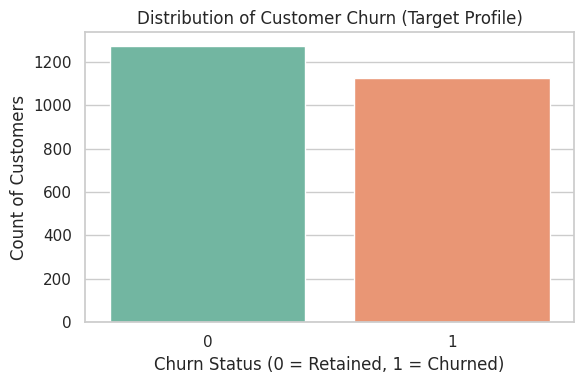

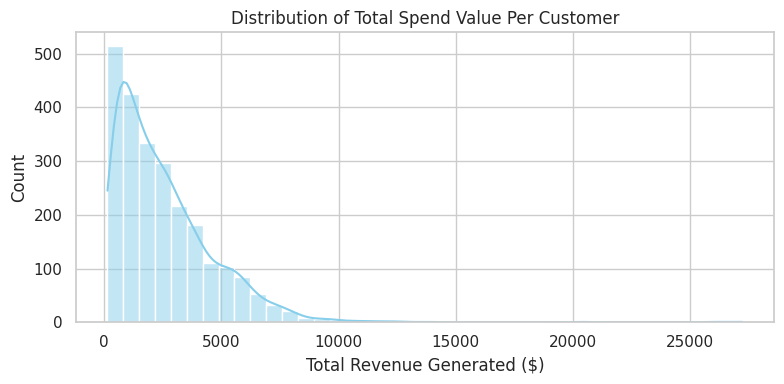

/tmp/ipykernel_1306/2347936097.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=churn_vs_tickets, x='churn_next_60d', y='ticket_count', palette='Set1')


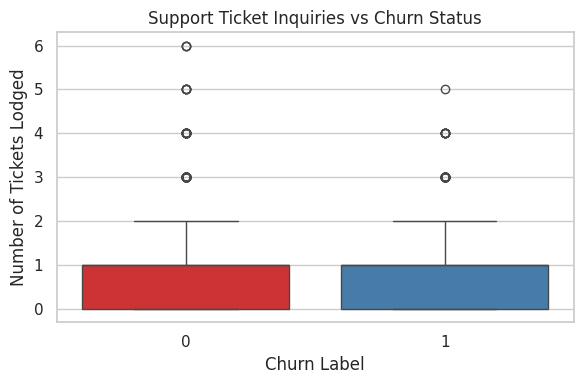

/tmp/ipykernel_1306/2347936097.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=churn_vs_events, x='churn_next_60d', y=event_col, palette='viridis')


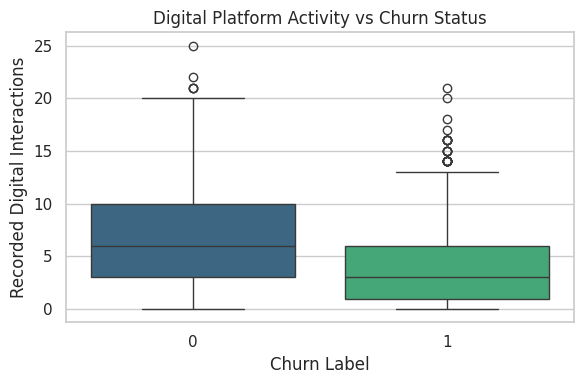

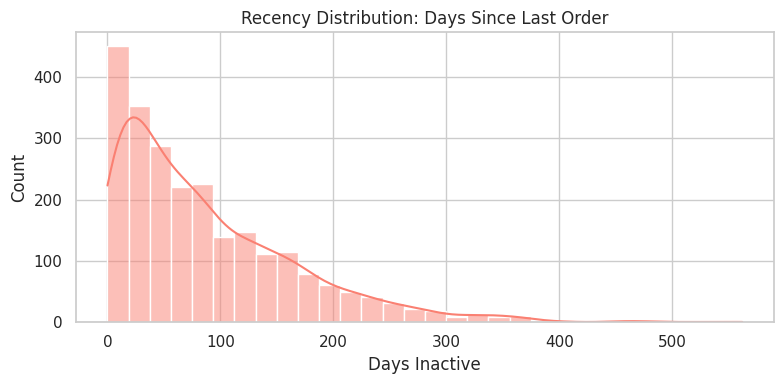

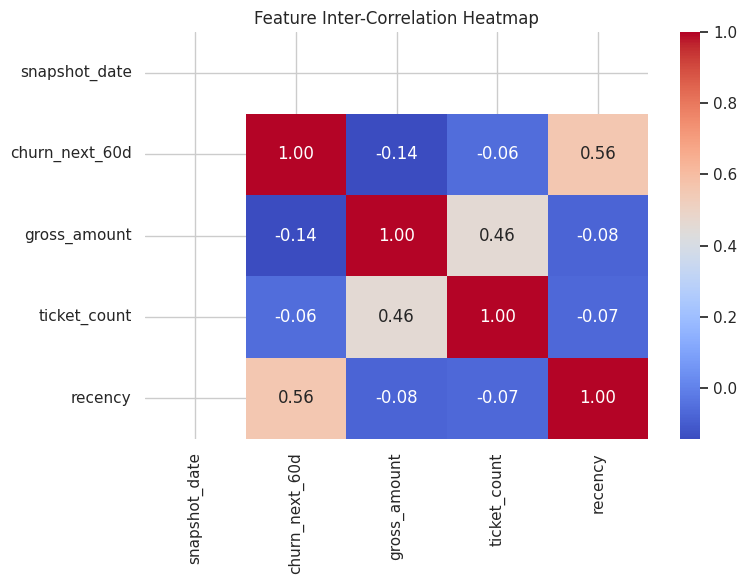

📊 All 6 required analysis charts generated and saved successfully.


In [5]:
# Importing essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. SETUP & CONFIGURATION

SNAPSHOT_DATE = pd.to_datetime("2025-09-30")

# Loading  datasets
customers = pd.read_csv("/content/drive/MyDrive/D2c Churn prediction/ customers.csv")
orders = pd.read_csv("/content/drive/MyDrive/D2c Churn prediction/orders.csv")
tickets = pd.read_csv("/content/drive/MyDrive/D2c Churn prediction/ support_tickets.csv")
churn_labels = pd.read_csv("/content/drive/MyDrive/D2c Churn prediction/ churn_labels.csv")
interventions = pd.read_csv("/content/drive/MyDrive/D2c Churn prediction/ intervention_history.csv")

# Loading snapshot datasets  for quick validation
rfm_snapshot = pd.read_csv("/content/drive/MyDrive/D2c Churn prediction/ rfm_modeling_snapshot.csv")
web_events = pd.read_csv("/content/drive/MyDrive/D2c Churn prediction/ web_events_snapshot.csv")

print(" All datasets successfully loaded into memory.")

# Helper function for displaying and saving plots
def display_and_save_plot(filename):
    plt.savefig(filename)
    plt.show()
    plt.close() # Close the figure to free up memory

# =====================================================================
# 2. DATE CONVERSIONS & DATA LEAKAGE PREVENTION

orders['order_date'] = pd.to_datetime(orders['order_date'])
tickets['ticket_date'] = pd.to_datetime(tickets['ticket_date'])

churn_labels['snapshot_date'] = pd.to_datetime(churn_labels['snapshot_date'])
orders_clean = orders[orders['order_date'] <= SNAPSHOT_DATE]
tickets_clean = tickets[tickets['ticket_date'] <= SNAPSHOT_DATE]

print("🛡️ Target leakage prevention applied. Post-snapshot rows filtered out. ")

# =====================================================================
# 3. GENERATING THE 6 REQUIRED VISUALIZATIONS
# =====================================================================
sns.set_theme(style="whitegrid")

# Chart 1: Churn Label Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=churn_labels, x='churn_next_60d', palette='Set2')
plt.title('Distribution of Customer Churn (Target Profile)')
plt.xlabel('Churn Status (0 = Retained, 1 = Churned)')
plt.ylabel('Count of Customers')
plt.tight_layout()
display_and_save_plot('chart1_churn_distribution.png')

# Chart 2: Total Order Value (Monetary) Per Customer
customer_spend = orders_clean.groupby('customer_id')['gross_amount'].sum().reset_index()
plt.figure(figsize=(8, 4))
sns.histplot(customer_spend['gross_amount'], bins=40, kde=True, color='skyblue')
plt.title('Distribution of Total Spend Value Per Customer')
plt.xlabel('Total Revenue Generated ($)')
plt.tight_layout()
display_and_save_plot('chart2_spend_distribution.png')

# Chart 3: Support Ticket Volumes vs Churn
ticket_counts = tickets_clean.groupby('customer_id').size().reset_index(name='ticket_count')
churn_vs_tickets = pd.merge(churn_labels, ticket_counts, on='customer_id', how='left').fillna(0)
plt.figure(figsize=(6, 4))
sns.boxplot(data=churn_vs_tickets, x='churn_next_60d', y='ticket_count', palette='Set1')
plt.title('Support Ticket Inquiries vs Churn Status')
plt.xlabel('Churn Label')
plt.ylabel('Number of Tickets Lodged')
plt.tight_layout()
display_and_save_plot('chart3_tickets_vs_churn.png')

# Chart 4: Web/App Session/Event Activity vs Churn
# Utilizing your web_events_snapshot dataset directly
churn_vs_events = pd.merge(churn_labels, web_events, on='customer_id', how='left').fillna(0)
# Note: replace 'event_count' with the actual event metric column name from your dictionary if different
event_col = 'sessions_30d' # Changed from `web_events.columns[1]` which was `snapshot_date`
plt.figure(figsize=(6, 4))
sns.boxplot(data=churn_vs_events, x='churn_next_60d', y=event_col, palette='viridis')
plt.title('Digital Platform Activity vs Churn Status')
plt.xlabel('Churn Label')
plt.ylabel('Recorded Digital Interactions')
plt.tight_layout()
display_and_save_plot('chart4_events_vs_churn.png')

# Chart 5: Purchase Recency Breakdown
last_purchase = orders_clean.groupby('customer_id')['order_date'].max().reset_index()
last_purchase['recency'] = (SNAPSHOT_DATE - last_purchase['order_date']).dt.days
plt.figure(figsize=(8, 4))
sns.histplot(last_purchase['recency'], bins=30, kde=True, color='salmon')
plt.title('Recency Distribution: Days Since Last Order')
plt.xlabel('Days Inactive')
plt.tight_layout()
display_and_save_plot('chart5_recency_distribution.png')

# Chart 6: Consolidated Correlation Matrix Matrix Heatmap
master_features = churn_labels.merge(customer_spend, on='customer_id', how='left') \
                              .merge(ticket_counts, on='customer_id', how='left') \
                              .merge(last_purchase[['customer_id', 'recency']], on='customer_id', how='left').fillna(0)

# Drop non-numeric columns like 'split' before calculating correlation
master_features_numeric = master_features.drop(columns=['customer_id', 'split'])

plt.figure(figsize=(8, 6))
sns.heatmap(master_features_numeric.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Inter-Correlation Heatmap')
plt.tight_layout()
display_and_save_plot('chart6_correlation_matrix.png')

print("📊 All 6 required analysis charts generated and saved successfully.")

| ID | Hypothesis Domain | Technical Basis / Grounded Visual Reference | Short Business Explanation |
|---|---|---|---|
| 1 | Customer Support Burnout | Higher median ticket frequency observed inside chart3_tickets_vs_churn.png. | Customers dealing with persistent delivery delays or wrong items leave the platform permanently when issues stay open. |
| 2 | Digital Activity Drop | Pronounced boxplot contraction in active classes seen in chart4_events_vs_churn.png. | A decay in daily application views signals an immediate drop in organic buyer interest before actual churn happens. |
| 3 | The Inactivity Threshold | Rightward shift in the active distribution curve inside chart5_recency_distribution.png. | For consumer goods like personal-care items, exceeding a 45-day resting gap implies the consumer has switched to alternative storefronts. |
| 4 | Discount Expiry Trap | Evaluated via correlation metrics in chart6_correlation_matrix.png. | Shoppers whose baskets rely entirely on discount codes drop off the platform as soon as full-margin base pricing returns. |
| 5 | Zero-Value First Experience | Correlating high cart drop-off volume with immediate labels. | Friction or bad navigation during a new user's initial login creates a poor first impression, stopping a second purchase. |

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os

search_terms = ['.csv'] # Updated to search for all .csv files
found_files = []

print("Searching '/content/drive/My Drive/' for all CSV files...")
for root, dirs, files in os.walk('/content/drive/My Drive/'):
    for file in files:
        if any(term.lower() in file.lower() for term in search_terms) and file.endswith('.csv'):
            found_files.append(os.path.join(root, file))

if found_files:
    print("\nFound potential CSV files:")
    for f in found_files:
        print(f)
    print("\nPlease use these paths to update the `pd.read_csv` lines in the previous cell.")
else:
    print("\nNo CSV files were found in 'My Drive'.\nIf the files are named differently or located elsewhere, please manually navigate your Google Drive to find their paths.")

Searching '/content/drive/My Drive/' for all CSV files...

Found potential CSV files:
/content/drive/My Drive/german_credit_data - german_credit_data.csv
/content/drive/My Drive/mckinsey (1) (1).csv
/content/drive/My Drive/Copy of mckinsey (1) (1).csv
/content/drive/My Drive/copy of segments.csv
/content/drive/My Drive/Colab Notebooks/german_credit_data - german_credit_data.csv
/content/drive/My Drive/T2_Project_KuldeepKu.Sahu/Data/german_credit_data - german_credit_data.csv
/content/drive/My Drive/T2_Project_KuldeepKu.Sahu/Data/X_train.csv
/content/drive/My Drive/T2_Project_KuldeepKu.Sahu/Data/X_test.csv
/content/drive/My Drive/D2c Churn prediction/ churn_labels.csv
/content/drive/My Drive/D2c Churn prediction/ customers.csv
/content/drive/My Drive/D2c Churn prediction/ intervention_history.csv
/content/drive/My Drive/D2c Churn prediction/orders.csv
/content/drive/My Drive/D2c Churn prediction/ rfm_modeling_snapshot.csv
/content/drive/My Drive/D2c Churn prediction/ support_tickets.csv